이 자료는 위키독스 딥 러닝을 이용한 자연어 처리 입문의 스팸 메일 분류하기 튜토리얼 자료입니다.  

링크 : https://wikidocs.net/22894  

In [1]:
import tensorflow as tf
tf.__version__

'2.19.0'

# 1. 스팸 메일 데이터에 대한 이해

In [2]:
# ============================================
# 🧠 텍스트 분류 실습을 위한 기본 라이브러리 불러오기
# ============================================

# 수학 계산에 자주 사용되는 라이브러리 (배열, 벡터 연산 등)
import numpy as np

# 데이터 분석에 사용되는 라이브러리 (표 형태 데이터 다루기)
import pandas as pd

# 그래프나 시각화를 위한 라이브러리
import matplotlib.pyplot as plt

# 인터넷에서 데이터(파일)를 다운로드할 때 사용하는 라이브러리
import urllib.request

# 학습용 데이터와 테스트용 데이터를 나누는 함수
from sklearn.model_selection import train_test_split

# 텍스트 데이터를 숫자로 바꾸는 도구 (단어를 정수로 인코딩)
from tensorflow.keras.preprocessing.text import Tokenizer

# 문장의 길이를 맞추기 위해 사용하는 도구 (짧은 문장은 0으로 채움)
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [4]:
# ============================================
# 📨 스팸 메일 데이터 다운로드 및 불러오기
# ============================================

# 인터넷 주소(URL)에서 데이터를 다운로드하여 파일로 저장하는 함수
# 첫 번째 인자: 다운로드할 파일의 주소(URL)
# 두 번째 인자: 저장할 파일 이름
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/ukairia777/tensorflow-nlp-tutorial/main/10.%20RNN%20Text%20Classification/dataset/spam.csv",
    filename="spam.csv"
)

# pandas를 이용해 CSV(Comma-Separated Values) 파일을 불러옴
# 'latin1' 인코딩은 영어 데이터셋을 읽을 때 깨짐을 방지하기 위한 설정
data = pd.read_csv('spam.csv', encoding='latin1')

# 데이터 확인 (처음 5행만 출력)
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
print('총 샘플의 수 :',len(data))

총 샘플의 수 : 5572


In [6]:
data[:5]

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
# 'Unnamed: 2' 열을 삭제
del data['Unnamed: 2']

# 'Unnamed: 3' 열을 삭제
del data['Unnamed: 3']

# 'Unnamed: 4' 열을 삭제
del data['Unnamed: 4']

# 'v1' 열에서 'ham'은 0으로, 'spam'은 1로 값을 대체
data['v1'] = data['v1'].replace(['ham', 'spam'], [0, 1])

# 데이터프레임의 상위 5개 행을 출력
data[:5]

/tmp/ipython-input-2641079961.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['v1'] = data['v1'].replace(['ham', 'spam'], [0, 1])


,v1,v2
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   int64 
 1   v2      5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB


In [9]:
print('결측값 여부 :',data.isnull().values.any())

결측값 여부 : False


In [10]:
print('v2열의 유니크한 값 :',data['v2'].nunique())

v2열의 유니크한 값 : 5169


In [11]:
# v2 열에서 중복인 내용이 있다면 중복 제거
data.drop_duplicates(subset=['v2'], inplace=True)

In [12]:
print('총 샘플의 수 :',len(data))

총 샘플의 수 : 5169


<Axes: xlabel='v1'>

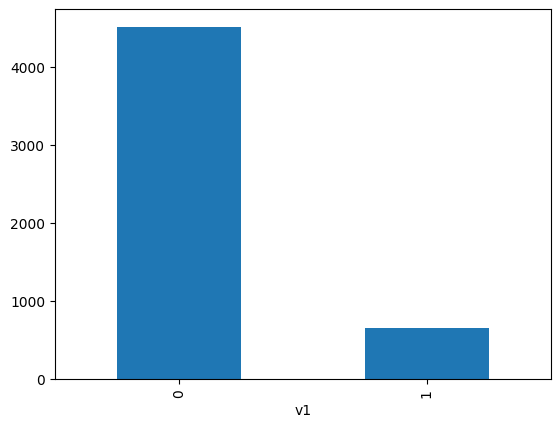

In [13]:
data['v1'].value_counts().plot(kind='bar')

In [14]:
print('정상 메일과 스팸 메일의 개수')
print(data.groupby('v1').size().reset_index(name='count'))

정상 메일과 스팸 메일의 개수
   v1  count
0   0   4516
1   1    653


In [15]:
print(f'정상 메일의 비율 = {round(data["v1"].value_counts()[0]/len(data) * 100,3)}%')
print(f'스팸 메일의 비율 = {round(data["v1"].value_counts()[1]/len(data) * 100,3)}%')

정상 메일의 비율 = 87.367%
스팸 메일의 비율 = 12.633%


In [16]:
X_data = data['v2']
y_data = data['v1']
print('메일 본문의 개수: {}'.format(len(X_data)))
print('레이블의 개수: {}'.format(len(y_data)))

메일 본문의 개수: 5169
레이블의 개수: 5169


현재 레이블이 굉장히 불균형하기 때문에 분리 후에도

훈련 데이터와 테스트 데이터의 레이블 비율이 유지되도록 해줍시다.

이는 인자로서 stratify=y데이터를 사용하여 가능합니다.

In [17]:
# ============================================
# 📊 학습용 데이터와 테스트용 데이터 나누기
# ============================================

# X_data : 입력 데이터 (메일 내용)
# y_data : 정답 데이터 (스팸 여부: ham=0, spam=1)
# test_size=0.2 : 전체 데이터 중 20%를 테스트용으로 사용
# random_state=0 : 랜덤 시드 고정 (결과를 항상 동일하게 재현 가능)
# stratify=y_data : 클래스 비율(스팸/일반 메일 비율)을 원본과 동일하게 유지

X_train, X_test, y_train, y_test = train_test_split(
    X_data,      # 입력 데이터
    y_data,      # 정답(라벨)
    test_size=0.2,      # 8:2 비율로 분할
    random_state=0,     # 무작위 분할 시 동일 결과 재현
    stratify=y_data     # 스팸/일반 비율이 학습·테스트 세트 모두 동일하게 유지되도록
)

In [18]:
print('--------훈련 데이터의 비율-----------')
print(f'정상 메일 = {round(y_train.value_counts()[0]/len(y_train) * 100,3)}%')
print(f'스팸 메일 = {round(y_train.value_counts()[1]/len(y_train) * 100,3)}%')

--------훈련 데이터의 비율-----------
정상 메일 = 87.376%
스팸 메일 = 12.624%


In [19]:
print('--------테스트 데이터의 비율-----------')
print(f'정상 메일 = {round(y_test.value_counts()[0]/len(y_test) * 100,3)}%')
print(f'스팸 메일 = {round(y_test.value_counts()[1]/len(y_test) * 100,3)}%')

--------테스트 데이터의 비율-----------
정상 메일 = 87.331%
스팸 메일 = 12.669%


In [20]:
# ============================================
# 🔠 텍스트 데이터를 숫자로 변환 (토큰화 + 정수 인코딩)
# ============================================

# 1️⃣ Tokenizer 객체 생성
# Tokenizer는 단어를 자동으로 숫자(index)로 바꿔주는 도구입니다.
tokenizer = Tokenizer()

# 2️⃣ 훈련 데이터의 모든 문장을 학습 (단어 사전 구축)
# fit_on_texts()는 X_train의 모든 단어를 읽고
# 각 단어에 고유한 번호(정수)를 부여합니다.
tokenizer.fit_on_texts(X_train)

# 3️⃣ 각 문장을 숫자 시퀀스로 변환
# texts_to_sequences()는 단어를 번호로 바꿔줍니다.
# 예: ["I love NLP"] → [[1, 23, 45]]
X_train_encoded = tokenizer.texts_to_sequences(X_train)

In [21]:
# ============================================
# 🔍 변환된 결과(정수 시퀀스) 일부 확인
# ============================================

# X_train_encoded에는 각 문장이 숫자 리스트(정수 시퀀스) 형태로 저장되어 있습니다.
# 예: "Free entry in 2 a wkly comp..." → [15, 203, 7, 64, 89, 30, ...]
# 아래 코드는 그 중 앞의 5개 문장만 출력하여 형태를 확인합니다.
print(X_train_encoded[:5])

[[102, 1, 210, 230, 3, 17, 39], [1, 59, 8, 427, 17, 5, 137, 2, 2326], [157, 180, 12, 13, 98, 93, 47, 9, 40, 3485, 247, 8, 7, 87, 6, 80, 1312, 5, 3486, 7, 2327, 11, 660, 306, 20, 25, 467, 708, 1028, 203, 129, 193, 800, 2328, 23, 1, 144, 71, 2, 111, 78, 43, 2, 130, 11, 800, 186, 122, 1512], [1, 1154, 13, 104, 292], [222, 622, 857, 540, 623, 22, 23, 83, 10, 47, 6, 257, 32, 6, 26, 64, 936, 407]]


In [22]:
# ============================================
# 📚 단어 사전(vocabulary) 확인하기
# ============================================

# Tokenizer는 fit_on_texts()를 통해
# 훈련 데이터의 모든 단어에 고유한 정수(index)를 자동으로 부여했습니다.
# word_index 속성에는
# {"단어": 번호} 형태의 딕셔너리(dictionary)가 저장되어 있습니다.
word_to_index = tokenizer.word_index

# 단어 사전 전체를 출력 (단어 → 숫자)
print(word_to_index)

{'i': 1, 'to': 2, 'you': 3, 'a': 4, 'the': 5, 'u': 6, 'and': 7, 'in': 8, 'is': 9, 'me': 10, 'my': 11, 'for': 12, 'your': 13, 'it': 14, 'of': 15, 'have': 16, 'on': 17, 'call': 18, 'that': 19, 'are': 20, '2': 21, 'now': 22, 'so': 23, 'but': 24, 'not': 25, 'can': 26, 'or': 27, "i'm": 28, 'get': 29, 'at': 30, 'do': 31, 'if': 32, 'be': 33, 'will': 34, 'just': 35, 'with': 36, 'we': 37, 'no': 38, 'this': 39, 'ur': 40, 'up': 41, '4': 42, 'how': 43, 'gt': 44, 'lt': 45, 'go': 46, 'when': 47, 'from': 48, 'what': 49, 'ok': 50, 'out': 51, 'know': 52, 'free': 53, 'all': 54, 'like': 55, 'then': 56, 'got': 57, 'good': 58, 'am': 59, 'time': 60, 'was': 61, 'come': 62, 'its': 63, 'love': 64, 'want': 65, 'text': 66, 'he': 67, 'only': 68, 'there': 69, 'day': 70, 'need': 71, 'going': 72, 'lor': 73, 'send': 74, 'one': 75, 'as': 76, 'home': 77, 'about': 78, 'back': 79, 'still': 80, 'k': 81, 'see': 82, 'txt': 83, 'by': 84, 'da': 85, 'stop': 86, 'r': 87, 'any': 88, 'tell': 89, 'dont': 90, "i'll": 91, "don't": 9

In [24]:
# ============================================
# 📊 희귀 단어(rare words) 비율 확인하기
# ============================================

# threshold : 희귀 단어를 정의할 기준값 (예: 2 → 2번 미만으로 등장한 단어를 희귀 단어로 간주)
threshold = 2

# 단어 집합의 전체 단어 수
total_cnt = len(word_to_index)

# 등장 빈도수가 threshold보다 작은 단어의 개수
rare_cnt = 0

# 전체 단어 등장 횟수 합계
total_freq = 0

# 희귀 단어의 등장 횟수 합계
rare_freq = 0

# Tokenizer는 각 단어의 등장 횟수를 word_counts 속성에 저장함
# → 예: {'movie': 123, 'great': 57, 'terrible': 8, 'loved': 1, ...}
for key, value in tokenizer.word_counts.items():
    total_freq += value  # 전체 단어 등장 횟수 누적

    # 만약 단어의 등장 횟수가 기준(threshold)보다 작다면 → 희귀 단어로 분류
    if value < threshold:
        rare_cnt += 1           # 희귀 단어 개수 증가
        rare_freq += value      # 희귀 단어의 등장 횟수 누적


# 결과 출력
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s' % (threshold - 1, rare_cnt))
print("단어 집합(vocabulary)에서 희귀 단어의 비율: %.2f%%" % ((rare_cnt / total_cnt) * 100))
print("전체 등장 빈도에서 희귀 단어의 등장 비율: %.2f%%" % ((rare_freq / total_freq) * 100))

등장 빈도가 1번 이하인 희귀 단어의 수: 4337
단어 집합(vocabulary)에서 희귀 단어의 비율: 55.45%
전체 등장 빈도에서 희귀 단어의 등장 비율: 6.66%


In [25]:
# ============================================
# 🧾 단어 집합(vocabulary) 크기 확인하기
# ============================================

# Tokenizer가 만든 단어 사전(word_index)의 총 단어 개수를 구함
# +1을 더하는 이유:
#   인덱스 0은 '패딩(padding)' 용도로 비워두기 때문
#   (즉, 실제 단어 번호는 1부터 시작)
vocab_size = len(word_to_index) + 1

# 단어 집합의 크기를 출력
print('단어 집합의 크기: {}'.format(vocab_size))

단어 집합의 크기: 7822


메일의 최대 길이 : 189
메일의 평균 길이 : 15.754534


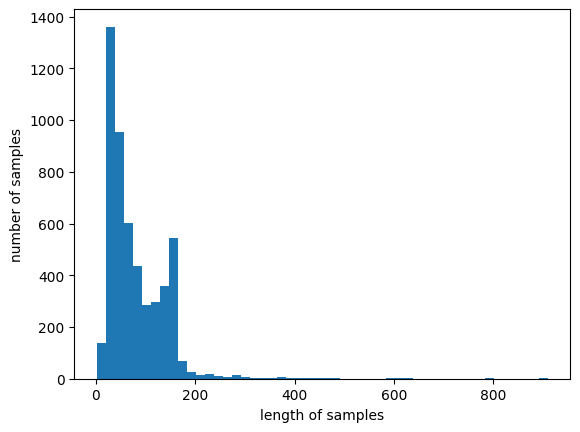

In [26]:
print('메일의 최대 길이 : %d' % max(len(l) for l in X_train_encoded))
print('메일의 평균 길이 : %f' % (sum(map(len, X_train_encoded))/len(X_train_encoded)))
plt.hist([len(s) for s in X_data], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [28]:
# ============================================
# 🧱 문장 길이 맞추기 (패딩, Padding)
# ============================================

# max_len : 문장의 최대 길이를 설정
# → 가장 긴 문장의 길이를 기준으로 하거나, 통계적으로 적절한 값을 선택
max_len = 189

# pad_sequences() : 모든 문장의 길이를 동일하게 맞춰주는 함수
# - maxlen : 최대 길이
# - 짧은 문장은 앞쪽에 0을 채워 넣음 (기본 설정: 'pre' padding)
# - 긴 문장은 뒤쪽을 잘라냄
X_train_padded = pad_sequences(X_train_encoded, maxlen=max_len)

# 패딩이 완료된 훈련 데이터의 형태 출력
# 예: (4457, 189) → 4457개 문장, 각 문장 길이는 189단어
print("훈련 데이터의 크기(shape): ", X_train_padded.shape)

훈련 데이터의 크기(shape):  (4135, 189)


# 2. RNN으로 스팸 메일 분류하기

“Sequential은 모델의 뼈대,
Embedding은 단어 입력 처리,
SimpleRNN은 문맥 이해,
Dense는 결과를 예측하는 층이다.”

| 구성요소           | 역할                           | 예시 설명                            |
| -------------- | ---------------------------- | -------------------------------- |
| **Sequential** | 층(layer)을 순차적으로 쌓아 만드는 모델 구조 | 입력층 → 은닉층 → 출력층 순서대로 구성          |
| **Embedding**  | 단어를 의미 벡터(숫자 벡터)로 변환하는 층     | 단어 ID → [0.12, 0.55, -0.33, ...] |
| **SimpleRNN**  | 순환신경망(RNN) 층                 | 문장 내 단어 순서와 문맥을 반영               |
| **Dense**      | 완전 연결층 (출력층 등에서 사용)          | 최종 분류 결과(예: 긍정/부정) 계산            |


In [29]:
# ============================================
# 🧠 RNN 모델 구성을 위한 Keras 모듈 불러오기
# ============================================

# 신경망의 층(Layer)을 구성하는 도구들
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense

# Sequential : 층을 순서대로 쌓아서 모델을 만드는 가장 기본적인 형태
from tensorflow.keras.models import Sequential

In [30]:
# ============================================
# 🧠 RNN 기반 텍스트 분류 모델 구성 및 학습
# ============================================

# 1️⃣ 순차적 모델(Sequential) 생성
# 층(layer)을 순서대로 쌓아 올릴 수 있는 가장 단순한 형태의 모델
model = Sequential()

# 2️⃣ Embedding 층
# - 단어를 고정된 크기의 벡터로 변환 (단어 → 숫자 벡터)
# - vocab_size : 단어 사전 크기 (입력 차원)
# - 32 : 각 단어를 32차원 벡터로 표현
model.add(Embedding(vocab_size, 32))

# 3️⃣ SimpleRNN 층
# - RNN 셀 32개를 사용하여 문장의 순서를 따라가며 문맥을 학습
# - RNN은 이전 단어의 정보를 다음 단어 해석에 반영
model.add(SimpleRNN(32))

# 4️⃣ 출력층(Dense)
# - 노드 1개: 긍정/부정 또는 스팸/일반 같은 이진 분류 문제에 사용
# - activation='sigmoid' : 결과를 0~1 사이 확률로 출력
model.add(Dense(1, activation='sigmoid'))

# 5️⃣ 모델 컴파일 (학습 준비)
# - optimizer='rmsprop' : RNN에 자주 사용되는 최적화 알고리즘
# - loss='binary_crossentropy' : 이진 분류(binary classification)에 적합한 손실 함수
# - metrics=['acc'] : 정확도(accuracy)를 평가 지표로 사용
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

# 6️⃣ 모델 학습 (fit)
# - X_train_padded : 입력 데이터 (패딩된 문장)
# - y_train : 정답(레이블)
# - epochs=10 : 데이터 전체를 10번 반복 학습
# - batch_size=64 : 한 번에 64개씩 학습
# - validation_split=0.2 : 훈련 데이터의 20%를 검증용으로 사용 (과적합 방지)
history = model.fit(
    X_train_padded,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 17s 174ms/step - acc: 0.8500 - loss: 0.4502 - val_acc: 0.9190 - val_loss: 0.2291
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.9552 - loss: 0.1742 - val_acc: 0.9710 - val_loss: 0.0988
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc: 0.9842 - loss: 0.0758 - val_acc: 0.9794 - val_loss: 0.0718
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - acc: 0.9905 - loss: 0.0403 - val_acc: 0.9794 - val_loss: 0.0709
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - acc: 0.9816 - loss: 0.0494 - val_acc: 0.9589 - val_loss: 0.1217
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9858 - loss: 0.0548 - val_acc: 0.9782 - val_loss: 0.0725
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - acc: 0.9943 - loss: 0.0221 - val_acc: 0.9794 - val_loss: 0.0779
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - acc: 0.9982 - loss: 0.0109 - val_acc: 0.9843 - val_loss: 0.0678
Epoch 9/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.99

In [31]:
# ============================================
# 🧾 테스트 데이터 전처리 (토큰화 + 패딩)
# ============================================

# 1️⃣ 테스트 데이터 문장을 숫자 시퀀스로 변환
# - 훈련 때 사용한 Tokenizer를 그대로 사용해야 함!
# - 단어 사전이 다르면 번호가 달라져 모델이 인식하지 못함
X_test_encoded = tokenizer.texts_to_sequences(X_test)

# 2️⃣ 모든 문장의 길이를 동일하게 맞추기 (패딩)
# - 훈련 데이터와 동일한 max_len을 사용해야 입력 크기가 일치함
X_test_padded = pad_sequences(X_test_encoded, maxlen=max_len)

# 3️⃣ 변환된 테스트 데이터의 형태 확인
print("테스트 데이터의 크기(shape):", X_test_padded.shape)

테스트 데이터의 크기(shape): (1034, 189)


In [33]:
print("\n 테스트 정확도: %.4f" % (model.evaluate(X_test_padded, y_test)[1]))

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9791 - loss: 0.0798

 테스트 정확도: 0.9758


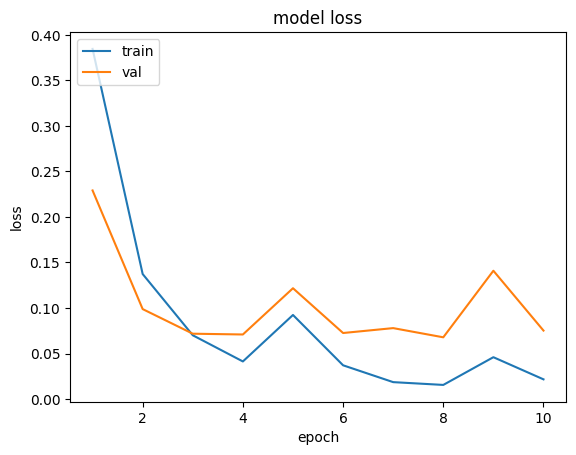

In [34]:
# ============================================
# 📉 학습 과정 시각화 (훈련/검증 손실 그래프)
# ============================================

# 1️⃣ 학습이 반복된 횟수(에포크 수) 설정
# history.history['acc']의 길이 = 학습이 반복된 총 횟수
epochs = range(1, len(history.history['acc']) + 1)

# 2️⃣ 훈련 데이터에서의 손실(loss) 값 그래프
plt.plot(epochs, history.history['loss'])

# 3️⃣ 검증 데이터에서의 손실(val_loss) 값 그래프
plt.plot(epochs, history.history['val_loss'])

# 4️⃣ 그래프 제목 및 축 이름 설정
plt.title('model loss')      # 그래프 제목
plt.ylabel('loss')           # y축: 손실값
plt.xlabel('epoch')          # x축: 학습 반복 횟수

# 5️⃣ 범례(legend) 표시
plt.legend(['train', 'val'], loc='upper left')

# 6️⃣ 그래프 출력
plt.show()